# Fit a model with two data groups

Some models use groups with different numbers of rows. Here, a zero-inflated
gamma model has one response for whether a value is zero and another for its
positive amount. We keep matching rows together within each group.

Start with {doc}`the first tutorial <09-liesel-optim-basic>` if you are new to
{class}`LieselOptim <liesel.optim.LieselOptim>`.

In [1]:
import logging

import jax.numpy as jnp
import numpy as np
import optax
import pandas as pd
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl
import liesel.optim as opt

logging.getLogger("liesel").setLevel(logging.WARNING)

## Simulate the two groups

The zero indicator has 1,000 rows. The gamma response contains only positive
observations, so it has fewer rows and its own design matrix.

In [2]:
rng = np.random.default_rng(202406)
x = rng.normal(size=1000)
X_zero_values = np.column_stack([np.ones_like(x), x])
alpha_true = np.array([-0.55, 1.10])
zero_probability = 1 / (1 + np.exp(-(X_zero_values @ alpha_true)))
zero_values = rng.binomial(1, zero_probability)

X_positive_values = X_zero_values[zero_values == 0]
beta_true = np.array([1.0, 0.65])
positive_mean = np.exp(X_positive_values @ beta_true)
positive_values = rng.gamma(shape=5.0, scale=positive_mean / 5.0)

In [3]:
pd.DataFrame(
    {"rows": [len(zero_values), len(positive_values)]},
    index=["all", "positive"],
)

,rows
all,1000
positive,618


## Build the model

Each group has its own coefficients. We fix the gamma concentration at 5 to
keep the example focused on handling the data.

In [4]:
# Probability of a zero response.
alpha = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=5.0),
    name="alpha",
)

X_zero = lsl.Var.new_obs(jnp.asarray(X_zero_values), name="X_zero")
logits = lsl.Var.new_calc(
    lambda X, a: X @ a,
    X_zero,
    alpha,
    name="logits",
)

zero = lsl.Var.new_obs(
    jnp.asarray(zero_values),
    dist=lsl.Dist(tfd.Binomial, total_count=1.0, logits=logits),
    name="zero",
)

# Mean of a positive response.
beta = lsl.Var.new_param(
    jnp.zeros(2),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=5.0),
    name="beta",
)

X_positive = lsl.Var.new_obs(
    jnp.asarray(X_positive_values),
    name="X_positive",
)
rate = lsl.Var.new_calc(
    lambda X, b: 5.0 / jnp.exp(X @ b),
    X_positive,
    beta,
    name="rate",
)

positive = lsl.Var.new_obs(
    jnp.asarray(positive_values),
    dist=lsl.Dist(tfd.Gamma, concentration=5.0, rate=rate),
    name="positive",
)

model = lsl.Model(zero, positive)

Plot the model to see how its variables depend on one another:

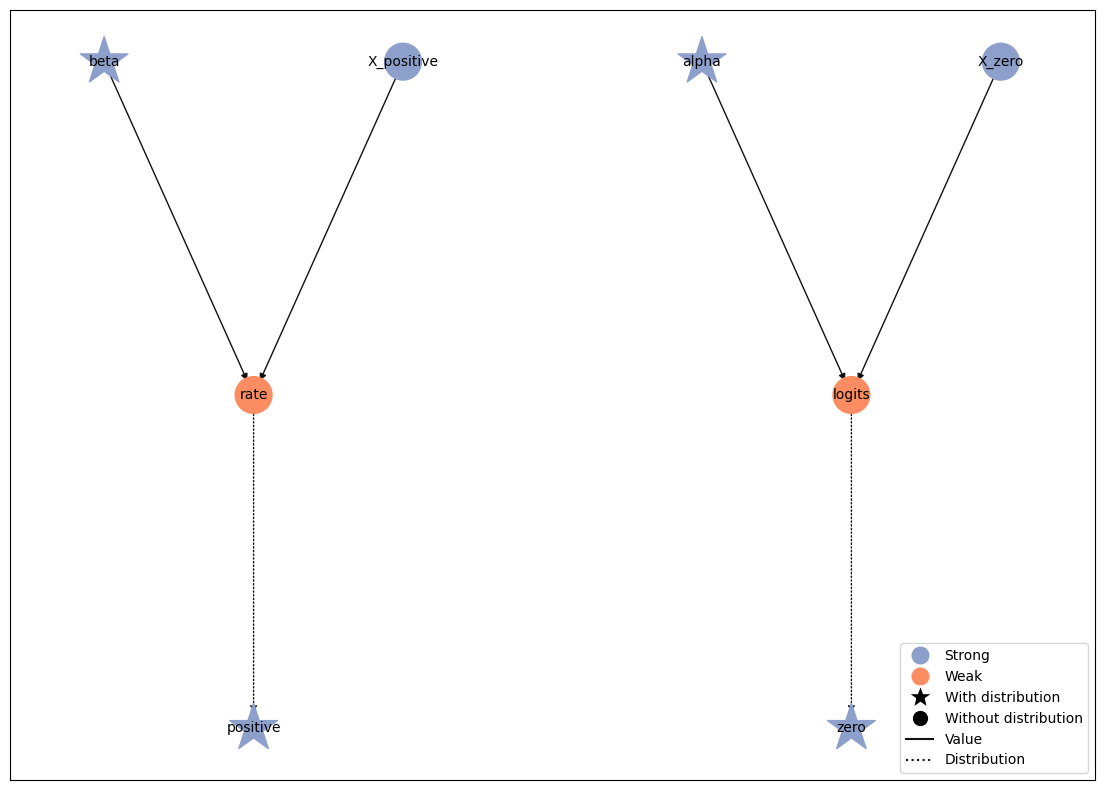

In [5]:
model.plot()

## Split each group

Each inner list names arrays that must share row indices. Groups split
independently. This example fits separate parameters for the two responses;
for a joint held-out prediction of the same people or events, split by that
shared identity before forming the groups.

In [6]:
split = opt.PositionSplitManager.from_model(
    model,
    position_keys=[["X_zero", "zero"], ["X_positive", "positive"]],
    validate_axis_share=0.2,
    seed=123,
)

In [7]:
pd.DataFrame(
    [
        {"keys": child.position_keys, "training_rows": child.train_axis_size}
        for child in split.splits
    ],
)

,keys,training_rows
0,"[X_zero, zero]",800
1,"[X_positive, positive]",495


## Fit both groups together

{meth}`Batches.from_split() <liesel.optim.Batches.from_split>` builds a {class}`BatchManager <liesel.optim.BatchManager>` for the two groups. Pass it to
{class}`LieselOptim <liesel.optim.LieselOptim>`. Each update uses 32 rows from each group. The default epoch length follows the larger group; the smaller
group starts another shuffled pass when needed. The loss scales each group's
batch to its training size.

In [8]:
batches = opt.Batches.from_split(split, batch_size=32)

result = opt.LieselOptim(
    model,
    split=split,
    batches=batches,
    optimizers=optax.adam(0.03),
    loss_monitor="validation",
    stopper=opt.Stopper(epochs=250, patience=30, rtol=1e-4),
    show_progress=False,
    seed=321,
).fit()
position = result.position_min_monitor

In [9]:
pd.DataFrame(
    {"zero": position["alpha"], "positive": position["beta"]},
    index=["intercept", "slope"],
).round(3)

,zero,positive
intercept,-0.588,1.000
slope,1.144,0.614


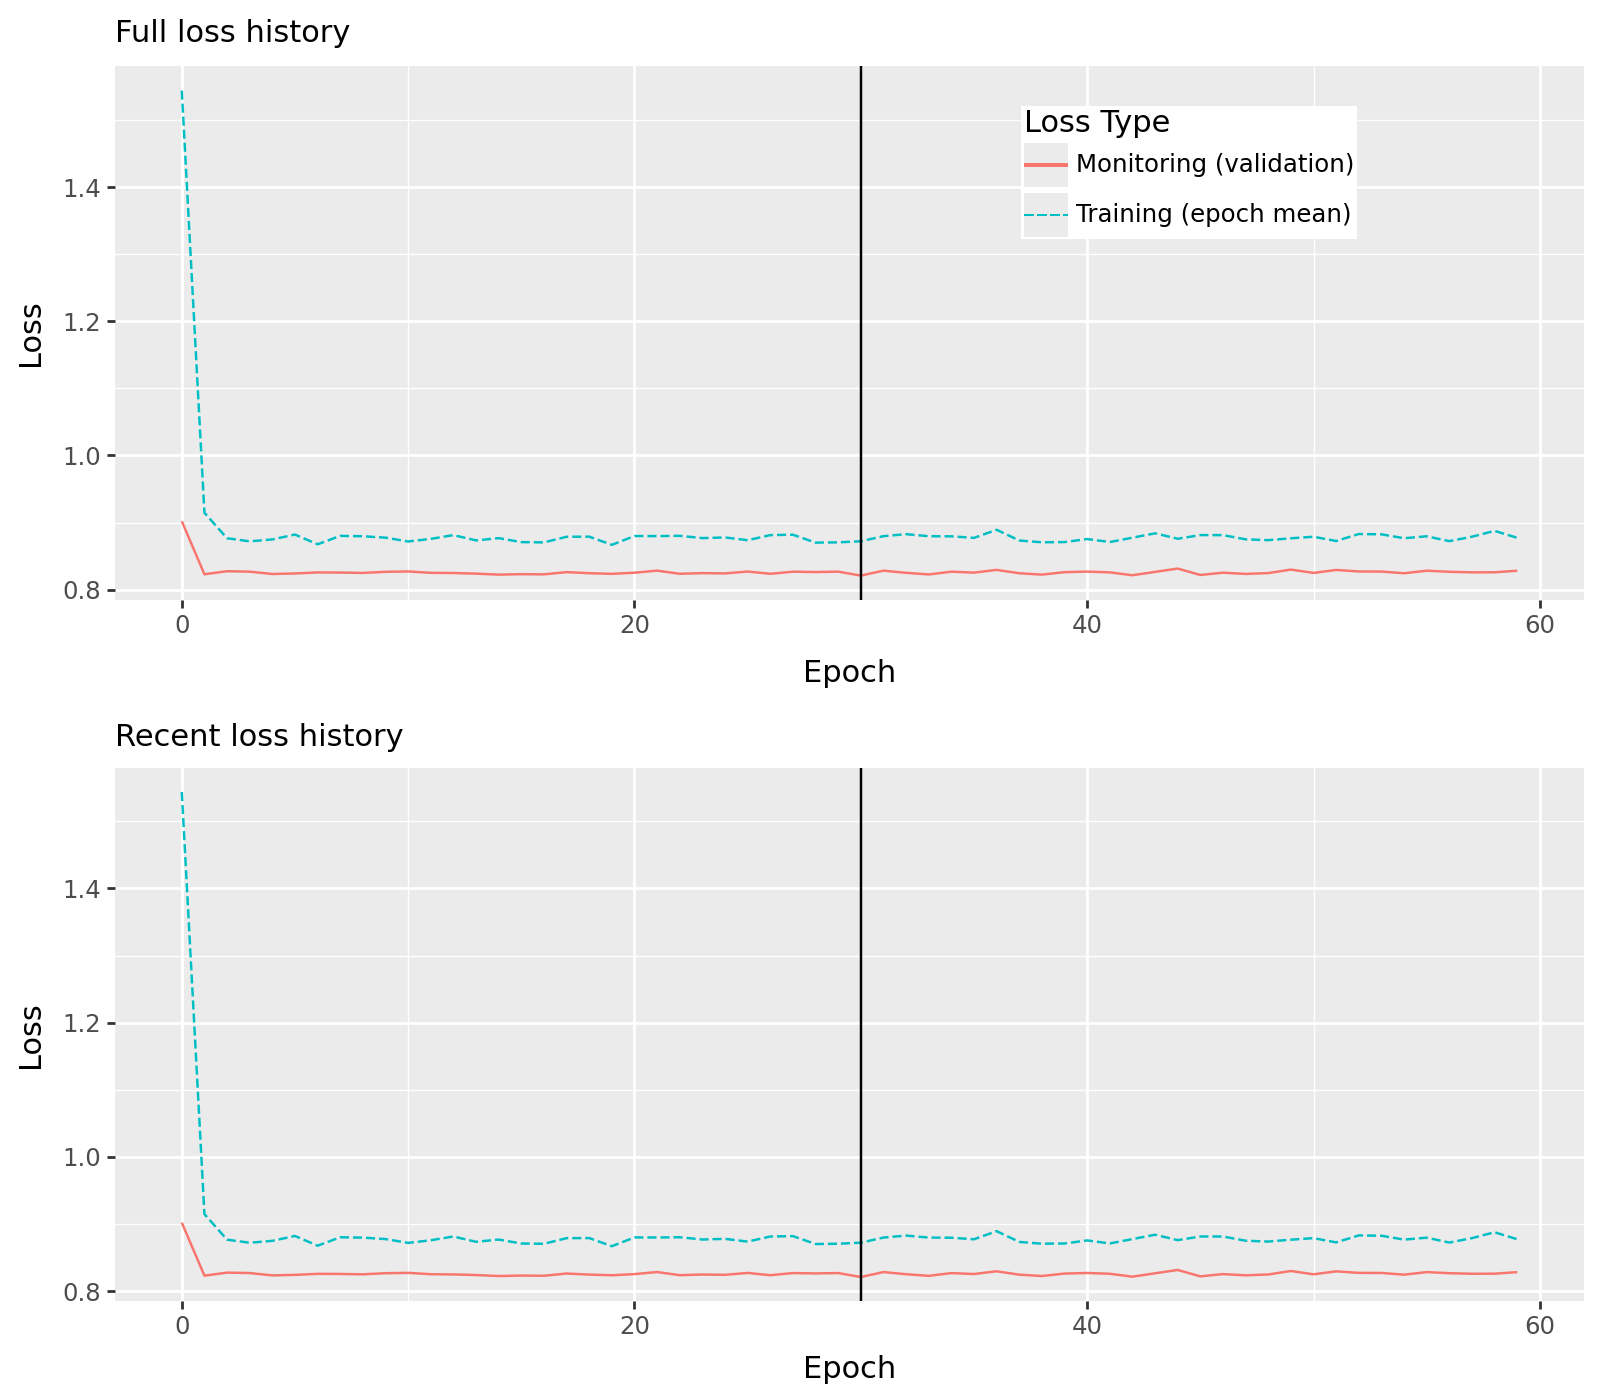

In [10]:
result.plot_loss_overview()

The zero-response coefficients (about −0.59 and 1.14) are close to the
simulated values −0.55 and 1.10. The positive-response coefficients (1.00 and
0.61) are also close to their targets 1.00 and 0.65.

Both loss curves fall sharply in the first few epochs and then fluctuate
around a stable level. The vertical line marks the lowest validation loss;
later updates bring little sustained improvement. The two panels show the
same range here because the run is shorter than the recent-history window.
These curves summarize both groups together, so they cannot show which
response accounts for any remaining lack of fit.

One optimizer can fit both groups. Use {doc}`separate optimizers <../../optimizer-customization>`
only when you want different update rules or learning rates. See
{doc}`splitting <../../optimizer-splitting>` for custom data axes,
{doc}`batching <../../optimizer-batching>` for other epoch lengths, and
{doc}`loss scaling <../../optimizer-loss-scaling>` for how each group contributes.